In [1]:
# Cell 1: mount Drive (for persistent logs/checkpoints)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%%bash
# Cell 2 (Bash): clone + install
set -e
git clone https://github.com/LukeTri/kfac-muon.git /content/kfac-muon || true
cd /content/kfac-muon
pip install -U pip
pip install -r requirements.txt
pip install timm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 91.7 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


Cloning into '/content/kfac-muon'...


In [3]:
# Cell 3 (Python): enter repo
%cd /content/kfac-muon


/content/kfac-muon


In [4]:
%%bash
# Cell 4 (Bash): download Food-101
set -e
cd /content/kfac-muon
python download_food101_vast.py \
  --source-root /content/data/torchvision \
  --out-root /content/data/food101 \
  --link-mode symlink \
  --overwrite


[download] Ensuring Food-101 is present via torchvision...
[prep] train split (symlink)
  wrote 5000 -> /content/data/food101/train
  wrote 10000 -> /content/data/food101/train
  wrote 15000 -> /content/data/food101/train
  wrote 20000 -> /content/data/food101/train
  wrote 25000 -> /content/data/food101/train
  wrote 30000 -> /content/data/food101/train
  wrote 35000 -> /content/data/food101/train
  wrote 40000 -> /content/data/food101/train
  wrote 45000 -> /content/data/food101/train
  wrote 50000 -> /content/data/food101/train
  wrote 55000 -> /content/data/food101/train
  wrote 60000 -> /content/data/food101/train
  wrote 65000 -> /content/data/food101/train
  wrote 70000 -> /content/data/food101/train
  wrote 75000 -> /content/data/food101/train
  wrote 75750 -> /content/data/food101/train
[prep] val split from test (symlink)
  wrote 5000 -> /content/data/food101/val
  wrote 10000 -> /content/data/food101/val
  wrote 15000 -> /content/data/food101/val
  wrote 20000 -> /content/da

100%|██████████| 5.00G/5.00G [04:15<00:00, 19.6MB/s]


In [14]:
%%bash
git pull

Updating de54120..584efbb
Fast-forward
 __pycache__/train.cpython-313.pyc | Bin 148153 -> 152106 bytes
 train.py                          |  60 +++++++++++++++++++++++++++++++++++++-
 2 files changed, 59 insertions(+), 1 deletion(-)


From https://github.com/LukeTri/kfac-muon
   de54120..584efbb  main       -> origin/main


In [17]:
# Run A: slightly more aggressive
CFG = {
    "out": "/content/drive/MyDrive/kfac-muon-logs/timm_train",
    "data_dir": "/content/data/food101",
    "resume_mode": "never",
    "exp": "vits16_food101_kfacmuon_reduced_update_freq",

    "dataset": "image_folder",
    "train_split": "train",
    "val_split": "val",
    "num_classes": 101,
    "model": "vit_small_patch16_224",
    "pretrained": False,

    "epochs": 60,
    "batch_size": 128,
    "workers": 4,
    "seed": 12,

    "amp": True,
    "amp_dtype": "bfloat16",

    "opt": "kfac_muon",
    "lr": "5.5e-4",
    "weight_decay": "0.07",
    "sched": "cosine",
    "warmup_epochs": 5,
    "min_lr": "1e-5",

    "mixup": "0.2",
    "cutmix": "0.2",
    "mixup_off_epoch": 45,
    "smoothing": "0.1",
    "reprob": "0.1",
    "drop_path": "0.1",

    "log_interval": 200,
    "val_interval": 1,
    "checkpoint_hist": 2,

    "opt_betas": ("0.9", "0.95"),
    "kfac_damping": "1.5e-4",
    "kfac_muon_eps": "0.038",
    "kfac_momentum": "0.9",
    "kfac_muon_lr_adjustment": "match_rms_adamw",
    "kfac_stats_update_every": 2,
    "kfac_factor_update_every": 2,
    "kfac_aux_no_decay": True,
}


In [ ]:
import glob, os, subprocess, torch

cfg = CFG
run_dir = os.path.join(cfg["out"], cfg["exp"])
os.makedirs(run_dir, exist_ok=True)

ckpts = sorted(glob.glob(os.path.join(run_dir, "checkpoint-*.pth.tar")))
resume_args = []

if cfg["resume_mode"] == "never":
    print("resume_mode=never -> start fresh")
elif len(ckpts) == 0:
    if cfg["resume_mode"] == "force":
        raise RuntimeError(f"resume_mode=force but no checkpoints in {run_dir}")
    print("no checkpoint found -> start fresh")
else:
    latest = ckpts[-1]
    print("found checkpoint:", latest)

    # PyTorch >=2.6 defaults weights_only=True; disable for full training-state checkpoints.
    try:
        ck = torch.load(latest, map_location="cpu", weights_only=False)
    except TypeError:
        ck = torch.load(latest, map_location="cpu")

    opt_state = ck.get("optimizer", {})
    if "kfac_reduce_state" not in opt_state:
        raise RuntimeError(
            "checkpoint missing kfac_reduce_state; refusing resume. "
            "Use a new exp or start fresh."
        )
    resume_args = ["--resume", latest]
    print("resuming from:", latest)


cmd = [
    "python", "train.py",
    "--data-dir", cfg["data_dir"],
    "--dataset", cfg["dataset"],
    "--train-split", cfg["train_split"],
    "--val-split", cfg["val_split"],
    "--num-classes", str(cfg["num_classes"]),
    "--model", cfg["model"],
    "--epochs", str(cfg["epochs"]),
    "--batch-size", str(cfg["batch_size"]),
    "--opt", cfg["opt"],
    "--lr", str(cfg["lr"]),
    "--weight-decay", str(cfg["weight_decay"]),
    "--sched", cfg["sched"],
    "--warmup-epochs", str(cfg["warmup_epochs"]),
    "--min-lr", str(cfg["min_lr"]),
    "--mixup", str(cfg["mixup"]),
    "--cutmix", str(cfg["cutmix"]),
    "--mixup-off-epoch", str(cfg["mixup_off_epoch"]),
    "--smoothing", str(cfg["smoothing"]),
    "--reprob", str(cfg["reprob"]),
    "--drop-path", str(cfg["drop_path"]),
    "--workers", str(cfg["workers"]),
    "--log-interval", str(cfg["log_interval"]),
    "--val-interval", str(cfg["val_interval"]),
    "--checkpoint-hist", str(cfg["checkpoint_hist"]),
    "--seed", str(cfg["seed"]),
    "--output", cfg["out"],
    "--experiment", cfg["exp"],
    "--opt-betas", cfg["opt_betas"][0], cfg["opt_betas"][1],
    "--kfac-damping", str(cfg["kfac_damping"]),
    "--kfac-muon-eps", str(cfg["kfac_muon_eps"]),
    "--kfac-momentum", str(cfg["kfac_momentum"]),
    "--kfac-muon-lr-adjustment", cfg["kfac_muon_lr_adjustment"],
    "--kfac-stats-update-every", str(cfg["kfac_stats_update_every"]),
    "--kfac-factor-update-every", str(cfg["kfac_factor_update_every"]),
]
if cfg["pretrained"]:
    cmd += ["--pretrained"]
if cfg["amp"]:
    cmd += ["--amp", "--amp-dtype", cfg["amp_dtype"]]
if cfg["kfac_aux_no_decay"]:
    cmd += ["--kfac-aux-no-decay"]
if cfg.get("profile_runtime", False):
    cmd += ["--profile-runtime"]
if cfg.get("profile_runtime_sync", False):
    cmd += ["--profile-runtime-sync"]


cmd += resume_args

print("Running:\n", " ".join(cmd))
subprocess.run(cmd, check=True, cwd="/content/kfac-muon")


resume_mode=never -> start fresh
Running:
 python train.py --data-dir /content/data/food101 --dataset image_folder --train-split train --val-split val --num-classes 101 --model vit_small_patch16_224 --epochs 60 --batch-size 128 --opt kfac_muon --lr 5.5e-4 --weight-decay 0.07 --sched cosine --warmup-epochs 5 --min-lr 1e-5 --mixup 0.2 --cutmix 0.2 --mixup-off-epoch 45 --smoothing 0.1 --reprob 0.1 --drop-path 0.1 --workers 4 --log-interval 200 --val-interval 1 --checkpoint-hist 2 --seed 12 --output /content/drive/MyDrive/kfac-muon-logs/timm_train --experiment vits16_food101_kfacmuon_reduced_update_freq --opt-betas 0.9 0.95 --kfac-damping 1.5e-4 --kfac-muon-eps 0.038 --kfac-momentum 0.9 --kfac-muon-lr-adjustment match_rms_adamw --kfac-stats-update-every 2 --kfac-factor-update-every 2 --amp --amp-dtype bfloat16 --kfac-aux-no-decay


Loaded 48 KFAC module states from:
/content/drive/MyDrive/kfac-muon-logs/timm_train/vits16_food101_kfacmuon_e60_lr5p5e4_seed11_damp1p5e4_eps0038/checkpoint-59.pth.tar



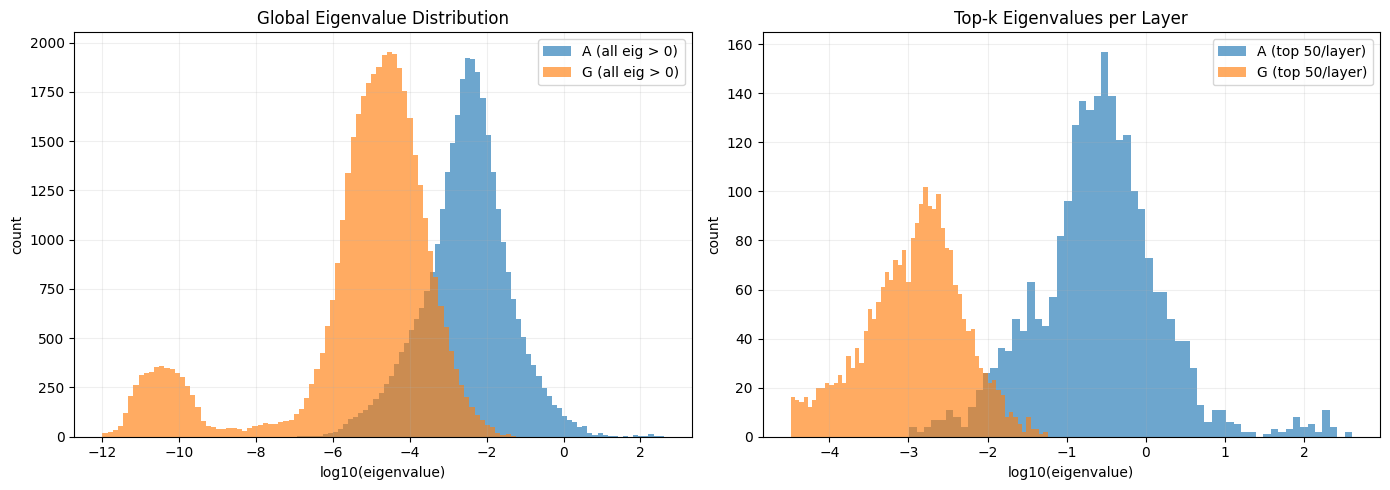

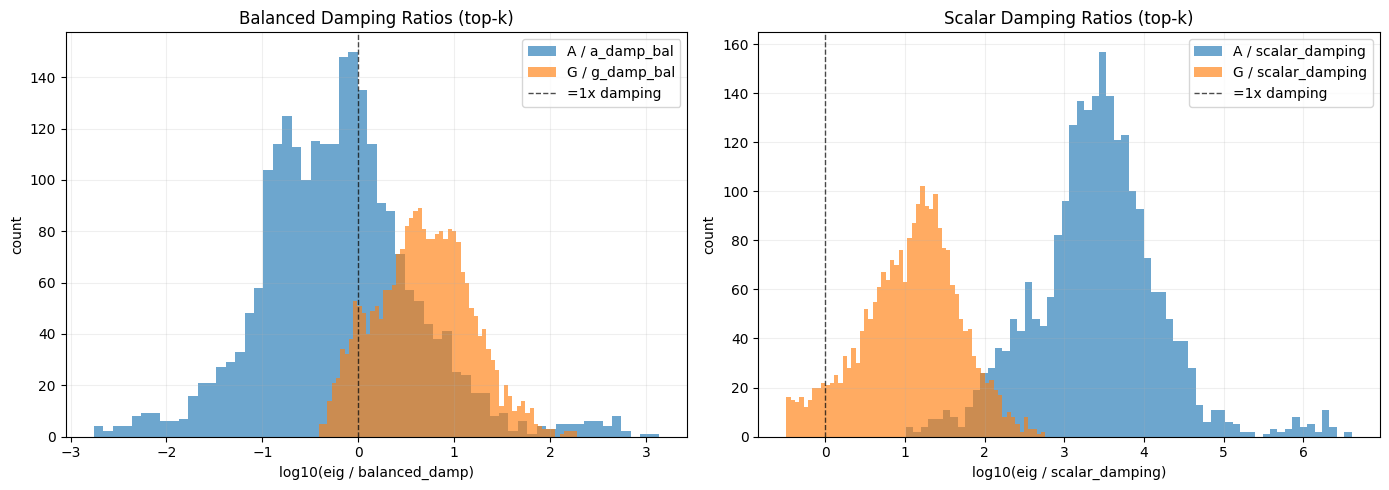

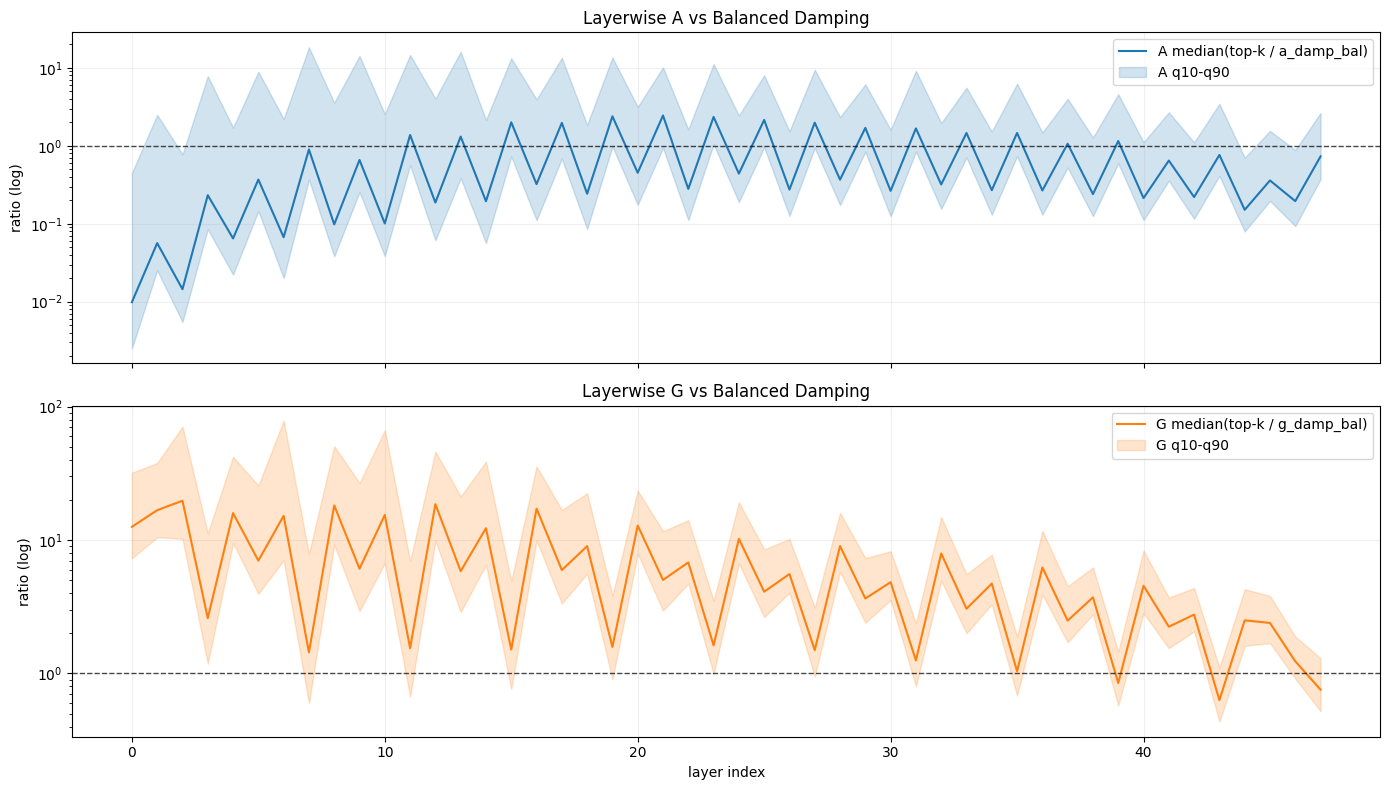

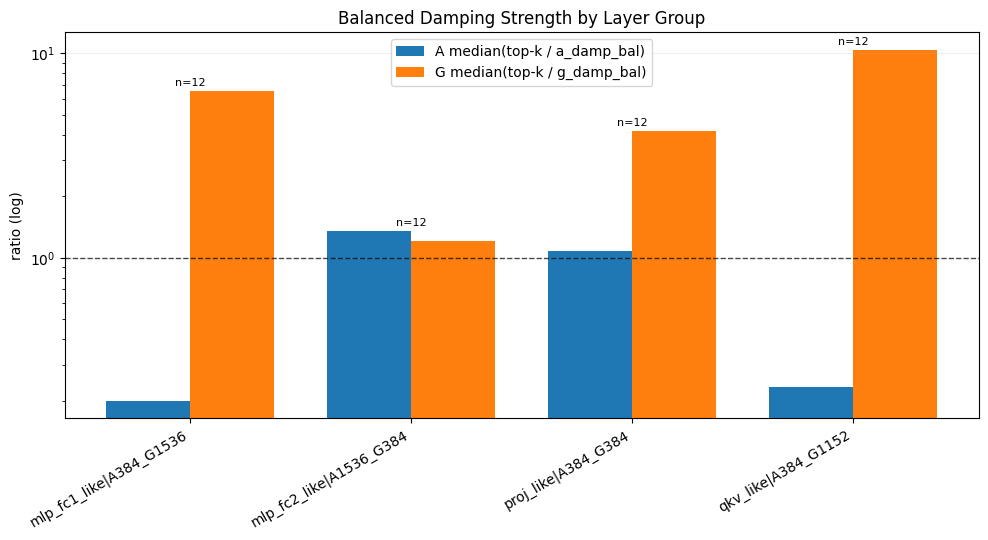


Saved:
 - /content/drive/MyDrive/kfac-muon-logs/spectrum_plots/layer_summary.csv
 - /content/drive/MyDrive/kfac-muon-logs/spectrum_plots/group_summary.csv
 - /content/drive/MyDrive/kfac-muon-logs/spectrum_plots/global_eig_hist.png
 - /content/drive/MyDrive/kfac-muon-logs/spectrum_plots/damping_ratio_hist.png
 - /content/drive/MyDrive/kfac-muon-logs/spectrum_plots/layerwise_balanced_ratios.png
 - /content/drive/MyDrive/kfac-muon-logs/spectrum_plots/grouped_balanced_ratios.png

Quick pooled stats (top-k, balanced):
  >0.3: A=0.648, G=1.000
  >1.0: A=0.367, G=0.901
  >3.0: A=0.165, G=0.662


In [9]:
# Single-cell KFAC spectrum diagnostics (A vs G)
# - Loads one checkpoint
# - Plots global eig distributions
# - Plots eig/damping ratios (balanced + scalar)
# - Plots layerwise medians
# - Plots grouped-by-layer-type medians
# - Writes layer/group CSV summaries

import os, math, csv
from collections import defaultdict
import numpy as np
import torch
import matplotlib.pyplot as plt

# ===================== USER SETTINGS =====================
ckpt_path = "/content/drive/MyDrive/kfac-muon-logs/timm_train/vits16_food101_kfacmuon_e60_lr5p5e4_seed11_damp1p5e4_eps0038/checkpoint-59.pth.tar"
outdir = "/content/drive/MyDrive/kfac-muon-logs/spectrum_plots"
damping = 1.0e-4          # IMPORTANT: set to actual damping used at this checkpoint epoch
topk = 50
rel_thresh = 1e-6         # "nontrivial eigs" threshold relative to layer max eig
max_groups_plot = 10
# =========================================================

os.makedirs(outdir, exist_ok=True)

def sym(x):
    return 0.5 * (x + x.T)

def q10_q50_q90(x):
    x = np.asarray(x, dtype=np.float64)
    if x.size == 0:
        return (np.nan, np.nan, np.nan)
    q = np.quantile(x, [0.1, 0.5, 0.9])
    return float(q[0]), float(q[1]), float(q[2])

def slog10(x, eps=1e-12):
    return np.log10(np.maximum(np.asarray(x, dtype=np.float64), eps))

def infer_kind(a_dim, g_dim):
    r = g_dim / max(a_dim, 1)
    if r >= 3.2:
        return "mlp_fc1_like"
    if r <= 0.33:
        return "mlp_fc2_like"
    if 2.3 <= r <= 3.2:
        return "qkv_like"
    if 0.8 <= r <= 1.2:
        return "proj_like"
    return "other"

def load_modules_state(ck):
    cand = []
    if isinstance(ck, dict):
        if isinstance(ck.get("optimizer"), dict):
            cand.append(ck["optimizer"].get("kfac_reduce_state"))
        cand.append(ck.get("kfac_reduce_state"))
    for c in cand:
        if isinstance(c, dict) and isinstance(c.get("modules_state"), list):
            return c["modules_state"]
    raise KeyError("Could not find checkpoint['optimizer']['kfac_reduce_state']['modules_state'].")

ck = torch.load(ckpt_path, map_location="cpu", weights_only=False)
mods = load_modules_state(ck)
print(f"Loaded {len(mods)} KFAC module states from:\n{ckpt_path}\n")

layers = []
for li, m in enumerate(mods):
    if "A" not in m or "G" not in m:
        continue
    A = sym(m["A"].float().cpu())
    G = sym(m["G"].float().cpu())

    eigA = torch.linalg.eigvalsh(A).cpu().numpy()
    eigG = torch.linalg.eigvalsh(G).cpu().numpy()
    posA = eigA[eigA > 1e-12]
    posG = eigG[eigG > 1e-12]

    topA = np.sort(posA)[-min(topk, posA.size):] if posA.size else np.array([])
    topG = np.sort(posG)[-min(topk, posG.size):] if posG.size else np.array([])

    mean_a = float(torch.trace(A).item() / A.shape[0])
    mean_g = float(torch.trace(G).item() / G.shape[0])

    # Balanced factor damping (same logic as training code)
    pi = math.sqrt(max(mean_a, 1e-12) / max(mean_g, 1e-12))
    root = math.sqrt(max(damping, 1e-12))
    a_damp = pi * root
    g_damp = root / pi

    topA_bal = topA / max(a_damp, 1e-12)
    topG_bal = topG / max(g_damp, 1e-12)
    topA_scalar = topA / max(damping, 1e-12)
    topG_scalar = topG / max(damping, 1e-12)

    thrA = max(rel_thresh * (float(np.max(posA)) if posA.size else 0.0), 1e-12)
    thrG = max(rel_thresh * (float(np.max(posG)) if posG.size else 0.0), 1e-12)
    nzA = posA[posA > thrA] if posA.size else np.array([])
    nzG = posG[posG > thrG] if posG.size else np.array([])

    layers.append({
        "idx": li,
        "a_dim": int(A.shape[0]),
        "g_dim": int(G.shape[0]),
        "kind": infer_kind(int(A.shape[0]), int(G.shape[0])),
        "ratio_g_over_a": float(G.shape[0] / max(A.shape[0], 1)),
        "mean_a": mean_a,
        "mean_g": mean_g,
        "a_damp": a_damp,
        "g_damp": g_damp,
        "posA": posA, "posG": posG,
        "topA": topA, "topG": topG,
        "topA_bal": topA_bal, "topG_bal": topG_bal,
        "topA_scalar": topA_scalar, "topG_scalar": topG_scalar,
        "nzA": nzA, "nzG": nzG
    })

if not layers:
    raise RuntimeError("No valid KFAC A/G layers found.")

# --------------------- CSV summaries ---------------------
layer_csv = os.path.join(outdir, "layer_summary.csv")
with open(layer_csv, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow([
        "layer_idx","kind","a_dim","g_dim","g_over_a","mean_a","mean_g","a_damp_bal","g_damp_bal",
        "A_top_q10","A_top_q50","A_top_q90","G_top_q10","G_top_q50","G_top_q90",
        "A_top_bal_q50","G_top_bal_q50","A_top_scalar_q50","G_top_scalar_q50",
        "nzA_count","nzG_count"
    ])
    for r in layers:
        A_q = q10_q50_q90(r["topA"])
        G_q = q10_q50_q90(r["topG"])
        A_bal_q = q10_q50_q90(r["topA_bal"])
        G_bal_q = q10_q50_q90(r["topG_bal"])
        A_sc_q = q10_q50_q90(r["topA_scalar"])
        G_sc_q = q10_q50_q90(r["topG_scalar"])
        w.writerow([
            r["idx"], r["kind"], r["a_dim"], r["g_dim"], r["ratio_g_over_a"], r["mean_a"], r["mean_g"], r["a_damp"], r["g_damp"],
            A_q[0], A_q[1], A_q[2], G_q[0], G_q[1], G_q[2],
            A_bal_q[1], G_bal_q[1], A_sc_q[1], G_sc_q[1],
            r["nzA"].size, r["nzG"].size
        ])

grouped = defaultdict(list)
for r in layers:
    key = f'{r["kind"]}|A{r["a_dim"]}_G{r["g_dim"]}'
    grouped[key].append(r)

group_csv = os.path.join(outdir, "group_summary.csv")
with open(group_csv, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["group","num_layers","A_bal_q10","A_bal_q50","A_bal_q90","G_bal_q10","G_bal_q50","G_bal_q90"])
    for k, rows in sorted(grouped.items(), key=lambda kv: (-len(kv[1]), kv[0])):
        A = np.concatenate([x["topA_bal"] for x in rows if x["topA_bal"].size > 0]) if rows else np.array([])
        G = np.concatenate([x["topG_bal"] for x in rows if x["topG_bal"].size > 0]) if rows else np.array([])
        Aq = q10_q50_q90(A); Gq = q10_q50_q90(G)
        w.writerow([k, len(rows), Aq[0], Aq[1], Aq[2], Gq[0], Gq[1], Gq[2]])

# ------------------------ Plots --------------------------
all_posA = np.concatenate([r["posA"] for r in layers if r["posA"].size > 0])
all_posG = np.concatenate([r["posG"] for r in layers if r["posG"].size > 0])
all_topA = np.concatenate([r["topA"] for r in layers if r["topA"].size > 0])
all_topG = np.concatenate([r["topG"] for r in layers if r["topG"].size > 0])

# 1) Global eig distributions
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(slog10(all_posA), bins=80, alpha=0.65, label="A (all eig > 0)")
ax[0].hist(slog10(all_posG), bins=80, alpha=0.65, label="G (all eig > 0)")
ax[0].set_title("Global Eigenvalue Distribution")
ax[0].set_xlabel("log10(eigenvalue)")
ax[0].set_ylabel("count")
ax[0].legend()
ax[0].grid(alpha=0.2)

ax[1].hist(slog10(all_topA), bins=60, alpha=0.65, label=f"A (top {topk}/layer)")
ax[1].hist(slog10(all_topG), bins=60, alpha=0.65, label=f"G (top {topk}/layer)")
ax[1].set_title("Top-k Eigenvalues per Layer")
ax[1].set_xlabel("log10(eigenvalue)")
ax[1].set_ylabel("count")
ax[1].legend()
ax[1].grid(alpha=0.2)
fig.tight_layout()
p1 = os.path.join(outdir, "global_eig_hist.png")
fig.savefig(p1, dpi=180)
plt.show()

# 2) Damping-ratio histograms (balanced vs scalar)
all_A_bal = np.concatenate([r["topA_bal"] for r in layers if r["topA_bal"].size > 0])
all_G_bal = np.concatenate([r["topG_bal"] for r in layers if r["topG_bal"].size > 0])
all_A_sc  = np.concatenate([r["topA_scalar"] for r in layers if r["topA_scalar"].size > 0])
all_G_sc  = np.concatenate([r["topG_scalar"] for r in layers if r["topG_scalar"].size > 0])

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(slog10(all_A_bal), bins=60, alpha=0.65, label="A / a_damp_bal")
ax[0].hist(slog10(all_G_bal), bins=60, alpha=0.65, label="G / g_damp_bal")
ax[0].axvline(0.0, linestyle="--", color="k", linewidth=1.0, alpha=0.7, label="=1x damping")
ax[0].set_title("Balanced Damping Ratios (top-k)")
ax[0].set_xlabel("log10(eig / balanced_damp)")
ax[0].set_ylabel("count")
ax[0].legend()
ax[0].grid(alpha=0.2)

ax[1].hist(slog10(all_A_sc), bins=60, alpha=0.65, label="A / scalar_damping")
ax[1].hist(slog10(all_G_sc), bins=60, alpha=0.65, label="G / scalar_damping")
ax[1].axvline(0.0, linestyle="--", color="k", linewidth=1.0, alpha=0.7, label="=1x damping")
ax[1].set_title("Scalar Damping Ratios (top-k)")
ax[1].set_xlabel("log10(eig / scalar_damping)")
ax[1].set_ylabel("count")
ax[1].legend()
ax[1].grid(alpha=0.2)
fig.tight_layout()
p2 = os.path.join(outdir, "damping_ratio_hist.png")
fig.savefig(p2, dpi=180)
plt.show()

# 3) Layerwise medians + q10/q90 bands
idx = np.array([r["idx"] for r in layers], dtype=np.int64)
ordr = np.argsort(idx)
idx = idx[ordr]
A_med = np.array([q10_q50_q90(r["topA_bal"])[1] for r in layers])[ordr]
A_q10 = np.array([q10_q50_q90(r["topA_bal"])[0] for r in layers])[ordr]
A_q90 = np.array([q10_q50_q90(r["topA_bal"])[2] for r in layers])[ordr]
G_med = np.array([q10_q50_q90(r["topG_bal"])[1] for r in layers])[ordr]
G_q10 = np.array([q10_q50_q90(r["topG_bal"])[0] for r in layers])[ordr]
G_q90 = np.array([q10_q50_q90(r["topG_bal"])[2] for r in layers])[ordr]

fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax[0].plot(idx, A_med, color="tab:blue", label="A median(top-k / a_damp_bal)")
ax[0].fill_between(idx, A_q10, A_q90, color="tab:blue", alpha=0.2, label="A q10-q90")
ax[0].axhline(1.0, linestyle="--", color="k", linewidth=1.0, alpha=0.7)
ax[0].set_yscale("log"); ax[0].set_ylabel("ratio (log)")
ax[0].set_title("Layerwise A vs Balanced Damping")
ax[0].legend(); ax[0].grid(alpha=0.2)

ax[1].plot(idx, G_med, color="tab:orange", label="G median(top-k / g_damp_bal)")
ax[1].fill_between(idx, G_q10, G_q90, color="tab:orange", alpha=0.2, label="G q10-q90")
ax[1].axhline(1.0, linestyle="--", color="k", linewidth=1.0, alpha=0.7)
ax[1].set_yscale("log"); ax[1].set_ylabel("ratio (log)")
ax[1].set_xlabel("layer index")
ax[1].set_title("Layerwise G vs Balanced Damping")
ax[1].legend(); ax[1].grid(alpha=0.2)
fig.tight_layout()
p3 = os.path.join(outdir, "layerwise_balanced_ratios.png")
fig.savefig(p3, dpi=180)
plt.show()

# 4) Grouped by layer type/shape
items = sorted(grouped.items(), key=lambda kv: (-len(kv[1]), kv[0]))[:max_groups_plot]
labels, Avals, Gvals, Ns = [], [], [], []
for k, rows in items:
    A = np.concatenate([r["topA_bal"] for r in rows if r["topA_bal"].size > 0]) if rows else np.array([])
    G = np.concatenate([r["topG_bal"] for r in rows if r["topG_bal"].size > 0]) if rows else np.array([])
    labels.append(k); Avals.append(q10_q50_q90(A)[1]); Gvals.append(q10_q50_q90(G)[1]); Ns.append(len(rows))

x = np.arange(len(labels)); w = 0.38
fig, ax = plt.subplots(figsize=(max(10, 1.6*len(labels)), 5.5))
ax.bar(x - w/2, Avals, w, label="A median(top-k / a_damp_bal)")
ax.bar(x + w/2, Gvals, w, label="G median(top-k / g_damp_bal)")
for i, n in enumerate(Ns):
    ymax = max(Avals[i], Gvals[i]) if np.isfinite(max(Avals[i], Gvals[i])) else 1.0
    ax.text(i, ymax * 1.03, f"n={n}", ha="center", va="bottom", fontsize=8)
ax.axhline(1.0, linestyle="--", color="k", linewidth=1.0, alpha=0.7)
ax.set_yscale("log")
ax.set_ylabel("ratio (log)")
ax.set_title("Balanced Damping Strength by Layer Group")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha="right")
ax.grid(axis="y", alpha=0.2); ax.legend()
fig.tight_layout()
p4 = os.path.join(outdir, "grouped_balanced_ratios.png")
fig.savefig(p4, dpi=180)
plt.show()

print("\nSaved:")
for p in [layer_csv, group_csv, p1, p2, p3, p4]:
    print(" -", p)

print("\nQuick pooled stats (top-k, balanced):")
def frac_gt(x, t):
    x = np.asarray(x, dtype=np.float64)
    return float(np.mean(x > t)) if x.size else float("nan")
for t in [0.3, 1.0, 3.0]:
    print(f"  >{t}: A={frac_gt(all_A_bal,t):.3f}, G={frac_gt(all_G_bal,t):.3f}")
